Install packages

In [1]:
!pip install -q pandas hestia-good seaborn rdkit transformers accelerate datasets


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Download ChEMBL

In [ ]:
 !curl -L -o chembl_36_sqlite.tar.gz https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/releases/chembl_36/chembl_36_sqlite.tar.gz
!tar -xzf chembl_36_sqlite.tar.gz
!ls -lh chembl_36/chembl_36_sqlite/chembl_36.db

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 5351M  100 5351M    0     0  24.9M      0  0:03:34  0:03:34 --:--:-- 29.3M
-rw-r--r-- 1 5012 1101 28G Sep 10  2025 chembl_36/chembl_36_sqlite/chembl_36.db


Query HCRTR1 data

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('chembl_36/chembl_36_sqlite/chembl_36.db')
query = """
SELECT cs.canonical_smiles, act.pchembl_value, act.standard_type
FROM activities act
JOIN assays a ON act.assay_id = a.assay_id
JOIN target_dictionary td ON a.tid = td.tid
JOIN compound_structures cs ON act.molregno = cs.molregno
WHERE td.chembl_id = 'CHEMBL5113'
  AND act.pchembl_value IS NOT NULL
  AND act.standard_relation = '='
"""
df_raw = pd.read_sql_query(query, conn)
print(df_raw.shape)
df_raw.head()

(10368, 3)


,canonical_smiles,pchembl_value,standard_type
0,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,4.18,Ki
1,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,7.89,Ki
2,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,6.57,Ki
3,COc1cc2c(cc1OC)CN(C(=O)C(Cc1ccc(Br)cc1)C(C)(C)...,5.16,IC50
4,COc1cc2c(cc1OC)CN(C(=O)C(Cc1ccccc1)NC(=O)c1cc(...,5.28,IC50


Clean and deduplicate

In [3]:
df_clean = df_raw.groupby('canonical_smiles')['pchembl_value'].median().reset_index()
df_clean = df_clean[df_clean['pchembl_value'] >= 5].reset_index(drop=True)
print(df_clean.shape)
df_clean.head()

(7090, 2)


,canonical_smiles,pchembl_value
0,C#CC1(c2ccccc2C(=O)N2C[C@H](Oc3nccn4c(C(F)F)cn...,5.750
1,C#Cc1cc(N2CC[C@@H]3CCN(C(=O)c4ccccc4-n4nccn4)C...,5.000
2,C#Cc1cccc(N2CC[C@@H]3CCN(C(=O)c4ccccc4-n4nccn4...,5.000
3,C#Cc1ccnc(O[C@@H]2CC[C@@H](C)N(C(=O)c3ccccc3-n...,6.965
4,C=C1CC(c2nc3c(Br)cccc3[nH]2)N(C(=O)c2cc(C)sc2-...,8.300


Load HCRTR1 data

In [4]:
import pandas as pd

# df_clean must already be loaded from your main notebook
# Run your ChEMBL query cells first, or paste df_clean here
df = df_clean[['canonical_smiles', 'pchembl_value']].copy()
df = df.rename(columns={'canonical_smiles': 'Drug', 'pchembl_value': 'Y'})
df = df.reset_index(drop=True)
print(df.shape)
df.head()

(7090, 2)


,Drug,Y
0,C#CC1(c2ccccc2C(=O)N2C[C@H](Oc3nccn4c(C(F)F)cn...,5.750
1,C#Cc1cc(N2CC[C@@H]3CCN(C(=O)c4ccccc4-n4nccn4)C...,5.000
2,C#Cc1cccc(N2CC[C@@H]3CCN(C(=O)c4ccccc4-n4nccn4...,5.000
3,C#Cc1ccnc(O[C@@H]2CC[C@@H](C)N(C(=O)c3ccccc3-n...,6.965
4,C=C1CC(c2nc3c(Br)cccc3[nH]2)N(C(=O)c2cc(C)sc2-...,8.300


Plot distribution

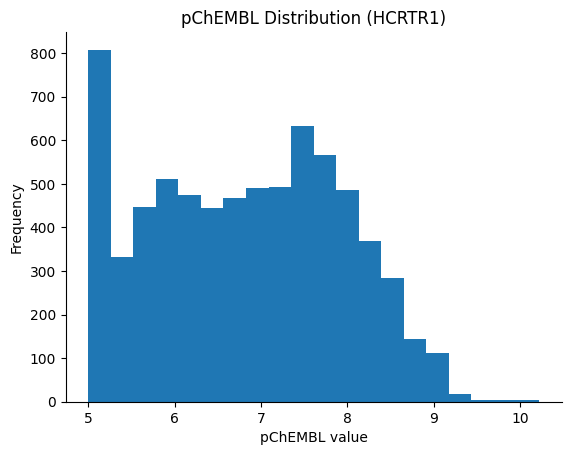

In [5]:
from matplotlib import pyplot as plt

df['Y'].plot(kind='hist', bins=20, title='pChEMBL Distribution (HCRTR1)')
plt.xlabel('pChEMBL value')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

Scaffold-based split

In [6]:
from hestia.partition import ccpart, random_partition
from hestia.similarity import molecular_similarity

sim_df = molecular_similarity(
    df_query=df,
    fingerprint='ecfp',
    radius=2,
    bits=2048,
    df=df,
    field_name='Drug',
    verbose=3
)

train, test, clusters = ccpart(
    df=df,
    sim_df=sim_df,
    test_size=0.2,
    threshold=0.4,
)
train_df = df.iloc[train, :].copy().reset_index(drop=True)
test_df  = df.iloc[test,  :].copy().reset_index(drop=True)

train, val = random_partition(train_df, test_size=0.1, random_state=42)
val_df   = train_df.iloc[val,   :].copy().reset_index(drop=True)
train_df = train_df.iloc[train, :].copy().reset_index(drop=True)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Calculating molecular similarities using ecfp with 2,048 bits, radius 2 and tanimoto index...


Query FPs: 100%|██████████| 7.09k/7.09k [00:00<00:00, 747kit/s]
Similarity calculation: 100%|██████████| 7.09k/7.09k [00:23<00:00, 299it/s]


Train: 5,741 | Val: 638 | Test: 711


Plot split distributions

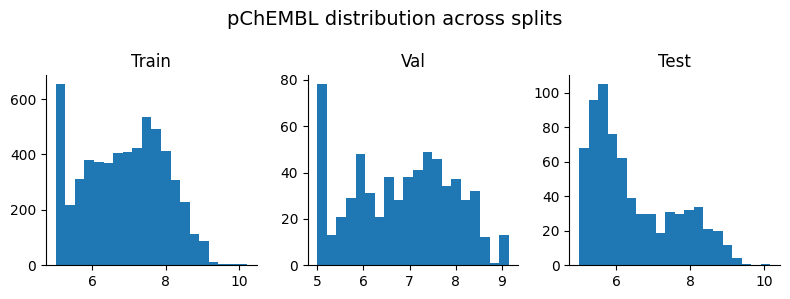

In [7]:
%matplotlib inline
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1, 3, dpi=100)
fig.suptitle("pChEMBL distribution across splits", fontsize=14)
fig.set_size_inches(8, 3)
ax[0].hist(train_df['Y'], bins=20); ax[0].set_title('Train')
ax[1].hist(val_df['Y'],   bins=20); ax[1].set_title('Val')
ax[2].hist(test_df['Y'],  bins=20); ax[2].set_title('Test')
for i in range(3):
    ax[i].spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

Define metrics

In [8]:
from typing import Any, Callable, List

import numpy as np
import torch
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import (f1_score, matthews_corrcoef,
                             precision_recall_curve, accuracy_score,
                             mean_squared_error, mean_absolute_error,
                             roc_auc_score, auc, confusion_matrix)
from sklearn.metrics.pairwise import cosine_similarity
import transformers as hf


class CustomTrainer(hf.Trainer):
    def save_model(self, output_dir: str = None, _internal_call: bool = False):
        device = self.model.device
        self.model = self.model.cpu()
        super().save_model(output_dir, _internal_call)
        self.model = self.model.to(device)


class Metrics:
    multilabel = False

    def __init__(self):
        self.metrics = {}

    def add_metric(self, name: str, metric: Callable):
        self.metrics[name] = metric

    def get_metrics(self, names: List[str], multilabel: bool = False):
        metrics = Metrics()
        metrics.multilabel = multilabel
        for name in names:
            if name in self.metrics:
                metrics.add_metric(name, self.metrics[name])
            else:
                raise ValueError(f"Metric: {name} not supported.",
                                 " Please use one of the following: ",
                                 f" {list(self.metrics.keys())}")
        return metrics

    def todict(self) -> dict:
        output = {}
        for name, fun in self.metrics.items():
            output[name] = fun
        return output

    def __call__(self, eval_prediction) -> Any:
        output = {}

        preds = eval_prediction.predictions
        refs = eval_prediction.label_ids
        if isinstance(preds, tuple):
            preds = preds[0]

        preds = np.asarray(preds)
        refs = np.asarray(refs)
        if preds.ndim > 1 and preds.shape[-1] == 1:
            preds = preds.reshape(-1)
        if refs.ndim > 1 and refs.shape[-1] == 1:
            refs = refs.reshape(-1)

        if len(preds.shape) < 2:
            pass
        elif preds.shape[1] > 1 and not self.multilabel:
            preds = np.argmax(preds, axis=1)

        if preds.dtype != refs.dtype or self.multilabel:
            preds = preds > (1 / preds.shape[1])

        for key, value in self.metrics.items():
            if key == 'cm':
                output2 = value(preds, refs)
                for k2, v2 in output2.items():
                    output[k2] = v2
            else:
                output[key] = value(preds, refs)[key]
        return output


def acc(predictions, references, **kwargs):
    return {"acc": accuracy_score(references, predictions)}

def auroc(predictions, references, **kwargs):
    return {"auroc": roc_auc_score(references, predictions)}

def cm_fun(predictions, references, **kwargs):
    cm = confusion_matrix(predictions, references)
    return {'tn': cm[0, 0], 'fp': cm[0, 1], 'tp': cm[1, 1], 'fn': cm[1, 0]}

def f1_binary(predictions, references, **kwargs):
    score = f1_score(references, predictions, average='binary', zero_division=0)
    return {"f1": float(score)}

def f1_weighted(predictions, references, **kwargs):
    score = f1_score(references, predictions, average='weighted', zero_division=0)
    return {"f1_weighted": float(score)}

def mcc(predictions, references, **kwargs):
    score = matthews_corrcoef(references, predictions)
    return {"mcc": float(score)}

def spcc(predictions, references, **kwargs):
    predictions = np.asarray(predictions).reshape(-1)
    references = np.asarray(references).reshape(-1)
    corr, _ = spearmanr(references, predictions)
    return {"spcc": float(corr)}

def pcc(predictions, references, **kwargs):
    predictions = np.asarray(predictions).reshape(-1)
    references = np.asarray(references).reshape(-1)
    corr, _ = pearsonr(references, predictions)
    return {"pcc": float(corr)}

def mse(predictions, references, **kwargs):
    return {'mse': mean_squared_error(references, predictions)}

def mae(predictions, references, **kwargs):
    return {'mae': mean_absolute_error(references, predictions)}

def aupr(predictions, references, **kwargs):
    precision, recall, _ = precision_recall_curve(y_true=references, probas_pred=predictions)
    return {'aupr': auc(precision, recall)}

def cosine(predictions, references, **kwargs):
    cosine = list(map(lambda x: cosine_similarity(x[0].reshape(1, -1), x[1].reshape(1, -1)).item(), predictions))
    cosine, references = np.array(cosine), np.array(references)
    score, _ = spearmanr(references, cosine)
    return {'cos': float(score)}

def manhattan(predictions, references, **kwargs):
    dist = list(map(lambda x: cdist(x[0].reshape(1, -1), x[1].reshape(1, -1), 'cityblock'), predictions))
    norm = list(map(lambda x: (np.linalg.norm(x[0].reshape(1, -1), 1) + np.linalg.norm(x[1].reshape(1, -1), 1)), predictions))
    dist = np.array([1 - (d / n).item() for d, n in zip(dist, norm)])
    score, _ = spearmanr(dist, references)
    return {'manhattan': float(score)}

def euclidean(predictions, references, **kwargs):
    dist = list(map(lambda x: cdist(x[0].reshape(1, -1), x[1].reshape(1, -1), 'euclidean'), predictions))
    norm = list(map(lambda x: (np.linalg.norm(x[0].reshape(1, -1), 2) + np.linalg.norm(x[1].reshape(1, -1), 2)), predictions))
    dist = np.array([1 - (d / n).item() for d, n in zip(dist, norm)])
    score, _ = spearmanr(dist, references)
    return {'euclidean': float(score)}


metrics_collection = Metrics()
metrics_collection.add_metric('acc', acc)
metrics_collection.add_metric('auroc', auroc)
metrics_collection.add_metric('f1', f1_binary)
metrics_collection.add_metric('f1_weighted', f1_weighted)
metrics_collection.add_metric('mcc', mcc)
metrics_collection.add_metric('spcc', spcc)
metrics_collection.add_metric('pcc', pcc)
metrics_collection.add_metric('mse', mse)
metrics_collection.add_metric('mae', mae)
metrics_collection.add_metric('aupr', aupr)
metrics_collection.add_metric('cm', cm_fun)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configure model

In [9]:
import copy
import transformers as hf
from datasets import Dataset

model_name = 'ibm/MoLFormer-XL-both-10pct'
num_labels = 1
metrics = ['pcc', 'spcc', 'mse', 'mae']

tokenizer = hf.AutoTokenizer.from_pretrained(
    model_name, max_length=250, trust_remote_code=True
)
model = hf.AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=num_labels, trust_remote_code=True
)

# Freeze bottom 6 of 12 transformer layers to limit catastrophic forgetting
for layer in model.molformer.encoder.layer[:6]:
    for param in layer.parameters():
        param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

hf_args = hf.TrainingArguments(
    output_dir='molformer',
    learning_rate=2e-5,                  # was 1e-4
    label_names=['labels'],
    metric_for_best_model='spcc',
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=12,                 # was 50
    greater_is_better=True,
    eval_accumulation_steps=1,
    load_best_model_at_end=False,        # disabled — no early stopping
    evaluation_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    report_to='tensorboard',
)

ds = {
    'train': Dataset.from_pandas(train_df),
    'val':   Dataset.from_pandas(val_df),
    'test':  Dataset.from_pandas(test_df)
}
for split in ds.keys():
    ds[split] = ds[split].map(
        lambda x: tokenizer(x['Drug'], truncation=True, padding='max_length', max_length=210)
    )
    ds[split] = ds[split].rename_column('Y', 'labels')
    ds[split] = ds[split].map(lambda x: {'labels': float(x['labels'])})
    ds[split].set_format(type='pt', columns=['input_ids', 'attention_mask', 'labels'])

trainer = CustomTrainer(
    copy.deepcopy(model),
    args=hf_args,
    train_dataset=ds['train'],
    eval_dataset=ds['val'],
    compute_metrics=metrics_collection.get_metrics(metrics),
    # EarlyStoppingCallback removed — random val set gives misleading early stopping signal
)

Some weights of MolformerForSequenceClassification were not initialized from the model checkpoint at ibm/MoLFormer-XL-both-10pct and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.dense2.bias', 'classifier.dense2.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Trainable: 24,277,249 / 45,556,993 (53.3%)


Map: 100%|██████████| 711/711 [00:00<00:00, 29313.50 examples/s]


Train

In [10]:
values = trainer.train()

  0%|          | 0/1080 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                  
  8%|▊         | 90/1080 [03:40<37:00,  2.24s/it]

{'eval_loss': 0.46853312849998474, 'eval_pcc': 0.8067386816444113, 'eval_spcc': 0.8037356785741975, 'eval_mse': 0.46853312849998474, 'eval_mae': 0.531050980091095, 'eval_runtime': 8.2779, 'eval_samples_per_second': 77.073, 'eval_steps_per_second': 1.208, 'epoch': 1.0}


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                   
 17%|█▋        | 180/1080 [07:12<30:43,  2.05s/it]

{'eval_loss': 0.40392765402793884, 'eval_pcc': 0.8454785880314688, 'eval_spcc': 0.846599306208093, 'eval_mse': 0.40392765402793884, 'eval_mae': 0.49417123198509216, 'eval_runtime': 8.0801, 'eval_samples_per_second': 78.96, 'eval_steps_per_second': 1.238, 'epoch': 2.0}


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                    
 25%|██▌       | 270/1080 [10:44<27:45,  2.06s/it]

...

{'loss': 0.2692, 'grad_norm': 6.426721572875977, 'learning_rate': 1.4814814814814815e-06, 'epoch': 11.11}


100%|██████████| 1080/1080 [43:12<00:00,  2.28s/it]/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                   
100%|██████████| 1080/1080 [43:22<00:00,  2.28s/it]

{'eval_loss': 0.3609350919723511, 'eval_pcc': 0.8782911987523576, 'eval_spcc': 0.8788047589549436, 'eval_mse': 0.3609350919723511, 'eval_mae': 0.45579424500465393, 'eval_runtime': 9.3926, 'eval_samples_per_second': 67.926, 'eval_steps_per_second': 1.065, 'epoch': 12.0}


100%|██████████| 1080/1080 [43:23<00:00,  2.41s/it]

{'train_runtime': 2603.7105, 'train_samples_per_second': 26.459, 'train_steps_per_second': 0.415, 'train_loss': 0.6385396498220938, 'epoch': 12.0}


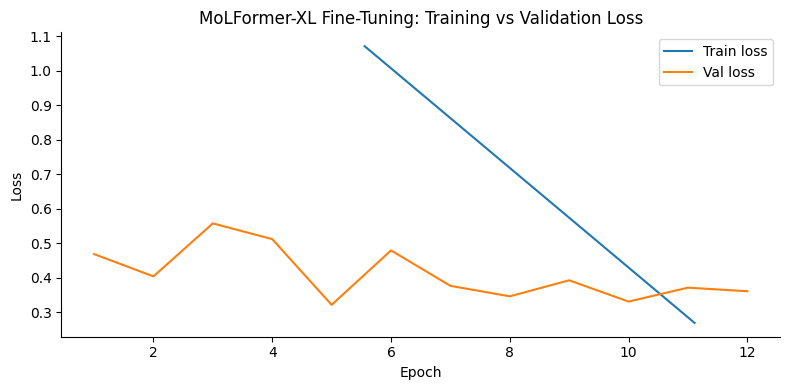

Best checkpoint: molformer/checkpoint-990


In [11]:
import matplotlib.pyplot as plt

log = trainer.state.log_history
train_loss = [(e['epoch'], e['loss'])      for e in log if 'loss' in e and 'eval_loss' not in e]
val_loss   = [(e['epoch'], e['eval_loss']) for e in log if 'eval_loss' in e]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(*zip(*train_loss), label='Train loss')
ax.plot(*zip(*val_loss),   label='Val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('MoLFormer-XL Fine-Tuning: Training vs Validation Loss')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('molformer_loss_curves.png', dpi=150)
plt.show()
print(f'Best checkpoint: {trainer.state.best_model_checkpoint}')

Evaluate

In [12]:
metrics_out = trainer.evaluate(eval_dataset=ds['test'], metric_key_prefix='test')
met_df = pd.DataFrame([metrics_out])
met_df.head()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 12/12 [00:09<00:00,  1.22it/s]


,test_loss,test_pcc,test_spcc,test_mse,test_mae,test_runtime,test_samples_per_second,test_steps_per_second,epoch
0,2.696171,0.031078,0.129387,2.696172,1.239148,11.2659,63.111,1.065,12.0
